PlantVillage dataset does not contain a wheat class.

Its 14 crops are apples, blueberries, cherries, corn, grapes, oranges, peaches, peppers, potatoes, raspberries, soybeans, squash and tomatoes. Wheat is not among them.

Therefore instead, the project will be:

# Air Quality Forecasting using Time Series Machine Learning Models

Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path to the dataset
file_path = "dataset.arff"

# Find where the actual data begins
with open(file_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

data_start = next(
    i for i, line in enumerate(lines)
    if line.strip().upper() == "@DATA"
)

# Column names from the ARFF file
columns = [
    "No", "year", "month", "day", "hour",
    "PM2.5", "PM10", "SO2", "NO2", "CO", "O3",
    "TEMP", "PRES", "DEWP", "RAIN",
    "wd", "WSPM", "station"
]

# Read only the observations
df = pd.read_csv(
    file_path,
    skiprows=data_start + 1,
    names=columns,
    na_values=["?", "NA", ""],
    low_memory=False
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (420768, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  str    
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 57.8 MB


The data contains null values

In [3]:
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


## Check the stations

In [4]:
print("Number of stations:", df["station"].nunique())

print("\nStations:")
print(df["station"].unique())

Number of stations: 12

Stations:
<StringArray>
[ 'Aotizhongxin',     'Changping',      'Dingling',        'Dongsi',
      'Guanyuan',       'Gucheng',       'Huairou',  'Nongzhanguan',
        'Shunyi',       'Tiantan',        'Wanliu', 'Wanshouxigong']
Length: 12, dtype: str


## Check missing values

In [5]:
missing = df.isnull().sum()

missing_percentage = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
})

missing_table = missing_table.sort_values(
    "Percentage",
    ascending=False
)

print(missing_table)

         Missing Values  Percentage
CO                20701    4.919813
O3                13277    3.155421
NO2               12116    2.879497
SO2                9021    2.143937
PM2.5              8739    2.076916
PM10               6449    1.532674
wd                 1822    0.433018
DEWP                403    0.095777
TEMP                398    0.094589
PRES                393    0.093401
RAIN                390    0.092688
WSPM                318    0.075576
year                  0    0.000000
No                    0    0.000000
day                   0    0.000000
month                 0    0.000000
hour                  0    0.000000
station               0    0.000000


Check duplicates and dates

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
print("Duplicate observation IDs:", df["No"].duplicated().sum())

Duplicate observation IDs: 385704


In [8]:
# Create datetime column
df["datetime"] = pd.to_datetime(
    df[["year", "month", "day", "hour"]]
)

# Sort chronologically by station
df = df.sort_values(
    ["station", "datetime"]
).reset_index(drop=True)

# Check that it worked
print(df[["year", "month", "day", "hour", "datetime"]].head())

   year  month  day  hour            datetime
0  2013      3    1     0 2013-03-01 00:00:00
1  2013      3    1     1 2013-03-01 01:00:00
2  2013      3    1     2 2013-03-01 02:00:00
3  2013      3    1     3 2013-03-01 03:00:00
4  2013      3    1     4 2013-03-01 04:00:00


In [9]:
print("Start:", df["datetime"].min())
print("End:", df["datetime"].max())

Start: 2013-03-01 00:00:00
End: 2017-02-28 23:00:00


In [10]:
print("Number of stations:", df["station"].nunique())
print(df["station"].unique())

Number of stations: 12
<StringArray>
[ 'Aotizhongxin',     'Changping',      'Dingling',        'Dongsi',
      'Guanyuan',       'Gucheng',       'Huairou',  'Nongzhanguan',
        'Shunyi',       'Tiantan',        'Wanliu', 'Wanshouxigong']
Length: 12, dtype: str


The dataset contains hourly air-quality observations collected from 12 monitoring stations in Beijing.

In [11]:
pollutants = [
    "PM2.5", "PM10", "SO2",
    "NO2", "CO", "O3"
]

for col in pollutants:
    print(f"\n--- {col} ---")
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())
    print("Values >= 999:")
    print((df[col] >= 999).sum())


--- PM2.5 ---
Minimum: 2.0
Maximum: 999.0
Values >= 999:
1

--- PM10 ---
Minimum: 2.0
Maximum: 999.0
Values >= 999:
3

--- SO2 ---
Minimum: 0.2856
Maximum: 500.0
Values >= 999:
0

--- NO2 ---
Minimum: 1.0265
Maximum: 290.0
Values >= 999:
0

--- CO ---
Minimum: 100.0
Maximum: 10000.0
Values >= 999:
184058

--- O3 ---
Minimum: 0.2142
Maximum: 1071.0
Values >= 999:
16


**A few values are >= 999**

Identify the suspicious 999+ values

In [12]:
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2']

for col in pollutants:
    print(f"\n--- {col} ---")
    print("Values >= 999:", (df[col] >= 999).sum())

    if (df[col] >= 999).sum() > 0:
        print(df.loc[df[col] >= 999, [col, 'station', 'datetime']])


--- PM2.5 ---
Values >= 999: 1
        PM2.5        station            datetime
411482  999.0  Wanshouxigong 2016-02-08 02:00:00

--- PM10 ---
Values >= 999: 3
         PM10    station            datetime
42951   999.0  Changping 2014-01-23 15:00:00
146075  999.0   Guanyuan 2013-10-29 11:00:00
299132  999.0     Shunyi 2015-04-15 20:00:00

--- SO2 ---
Values >= 999: 0

--- NO2 ---
Values >= 999: 0


Convert the invalid 999 values to missing

In [13]:
import numpy as np

In [14]:
df['PM2.5'] = df['PM2.5'].replace(999, np.nan)
df['PM10'] = df['PM10'].replace(999, np.nan)

In [15]:
print("PM2.5 missing:", df['PM2.5'].isna().sum())
print("PM10 missing:", df['PM10'].isna().sum())

PM2.5 missing: 8740
PM10 missing: 6452


In [16]:
missing_summary = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().sum() / len(df)) * 100
})

missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

print(missing_summary.sort_values('Missing Count', ascending=False))

       Missing Count  Missing %
CO             20701   4.919813
O3             13277   3.155421
NO2            12116   2.879497
SO2             9021   2.143937
PM2.5           8740   2.077154
PM10            6452   1.533387
wd              1822   0.433018
DEWP             403   0.095777
TEMP             398   0.094589
PRES             393   0.093401
RAIN             390   0.092688
WSPM             318   0.075576


Make sure datetime is actually datetime and sorted:

In [17]:
df['datetime'] = pd.to_datetime(df['datetime'])

df = df.sort_values(['station', 'datetime'])

In [18]:
continuous_cols = [
    'PM2.5', 'PM10', 'CO', 'SO2', 'NO2', 'O3',
    'DEWP', 'TEMP', 'PRES', 'RAIN', 'WSPM'
]

df[continuous_cols] = (
    df.groupby('station')[continuous_cols]
      .transform(lambda x: x.interpolate(method='linear'))
)

In [19]:
df['wd'] = (
    df.groupby('station')['wd']
      .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))
)

In [20]:
print(df.isna().sum())

No           0
year         0
month        0
day          0
hour         0
PM2.5        0
PM10         0
SO2          0
NO2         22
CO           0
O3           0
TEMP         0
PRES         0
DEWP         0
RAIN         0
wd           0
WSPM         0
station      0
datetime     0
dtype: int64


In [21]:
print("Remaining PM2.5 missing values:",
      df['PM2.5'].isna().sum())

Remaining PM2.5 missing values: 0


In [22]:
print(df[df['PM2.5'].isna()][['station', 'datetime', 'PM2.5']].head(20))

Empty DataFrame
Columns: [station, datetime, PM2.5]
Index: []


Interpolate NO2 values

In [23]:
df['NO2'] = (
    df.groupby('station')['NO2']
      .transform(lambda x: x.interpolate(method='linear'))
)

In [24]:
print("Remaining NO2 missing values:", df['NO2'].isna().sum())

Remaining NO2 missing values: 22


In [25]:
print(df.isna().sum())

No           0
year         0
month        0
day          0
hour         0
PM2.5        0
PM10         0
SO2          0
NO2         22
CO           0
O3           0
TEMP         0
PRES         0
DEWP         0
RAIN         0
wd           0
WSPM         0
station      0
datetime     0
dtype: int64


In [26]:
df[df['NO2'].isna()][['station', 'datetime', 'NO2']]

,station,datetime,NO2
70128,Dingling,2013-03-01 00:00:00,NaN
70129,Dingling,2013-03-01 01:00:00,NaN
175320,Gucheng,2013-03-01 00:00:00,NaN
175321,Gucheng,2013-03-01 01:00:00,NaN
175322,Gucheng,2013-03-01 02:00:00,NaN
175323,Gucheng,2013-03-01 03:00:00,NaN
175324,Gucheng,2013-03-01 04:00:00,NaN
175325,Gucheng,2013-03-01 05:00:00,NaN
175326,Gucheng,2013-03-01 06:00:00,NaN
175327,Gucheng,2013-03-01 07:00:00,NaN


In [27]:
df['NO2'] = (
    df.groupby('station')['NO2']
      .transform(lambda x: x.interpolate(method='linear')
                            .ffill()
                            .bfill())
)

In [28]:
print("Remaining NO2 missing:", df['NO2'].isna().sum())

Remaining NO2 missing: 0


In [29]:
print(df.isna().sum())

No          0
year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
datetime    0
dtype: int64


**Missing numerical air-quality observations were handled using station-level linear interpolation, with forward/backward filling applied to remaining boundary missing values.**

## Verify the cleaned dataset

In [30]:
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,datetime
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.839344,104.904013,15.913090,50.599018,1235.682649,57.237872,13.531692,1010.753337,2.482421,0.064428,1.730034,2015-03-01 11:30:00
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000,2013-03-01 00:00:00
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,10.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000,2014-03-01 05:45:00
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,44.000000,14.500000,1010.400000,3.000000,0.000000,1.400000,2015-03-01 11:30:00
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000,2016-02-29 17:15:00
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,957.000000,995.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000,2017-02-28 23:00:00
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.946331,92.399342,21.896609,35.171921,1161.790893,57.135195,11.437867,10.474302,13.797675,0.820638,1.246674,NaN


In [31]:
df['PM2.5'].describe()

count    420768.000000
mean         79.839344
std          80.946331
min           2.000000
25%          20.000000
50%          55.000000
75%         111.000000
max         957.000000
Name: PM2.5, dtype: float64

In [32]:
print("PM2.5 >= 500:", (df['PM2.5'] >= 500).sum())
print("PM2.5 >= 300:", (df['PM2.5'] >= 300).sum())

PM2.5 >= 500: 969
PM2.5 >= 300: 10203


Check PM2.5 by station

In [33]:
df.groupby('station')['PM2.5'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).sort_values('mean', ascending=False)

,count,mean,median,min,max
station,,,,,
Dongsi,35064,86.144243,61.0,3.0,737.0
Nongzhanguan,35064,85.079472,59.0,2.0,844.0
Wanshouxigong,35064,85.063056,60.0,3.0,857.0
Gucheng,35064,84.074802,60.0,2.0,770.0
Wanliu,35064,83.467612,59.0,2.0,957.0
Guanyuan,35064,82.897522,59.0,2.0,680.0
Aotizhongxin,35064,82.540623,58.0,3.0,898.0
Tiantan,35064,82.033097,58.0,3.0,821.0
Shunyi,35064,79.437962,55.0,2.0,941.0


Check the time period

In [34]:
print("Start:", df['datetime'].min())
print("End:", df['datetime'].max())

Start: 2013-03-01 00:00:00
End: 2017-02-28 23:00:00


In [35]:
print(df['datetime'].is_monotonic_increasing)

False


In [36]:
print(
    df.groupby('station')['datetime']
      .apply(lambda x: x.is_monotonic_increasing)
)

station
Aotizhongxin     True
Changping        True
Dingling         True
Dongsi           True
Guanyuan         True
Gucheng          True
Huairou          True
Nongzhanguan     True
Shunyi           True
Tiantan          True
Wanliu           True
Wanshouxigong    True
Name: datetime, dtype: bool


## Exploratory time-series analysis

In [37]:
print("Start:", df['datetime'].min())
print("End:", df['datetime'].max())

Start: 2013-03-01 00:00:00
End: 2017-02-28 23:00:00


In [38]:
print(df.groupby('station').size())

station
Aotizhongxin     35064
Changping        35064
Dingling         35064
Dongsi           35064
Guanyuan         35064
Gucheng          35064
Huairou          35064
Nongzhanguan     35064
Shunyi           35064
Tiantan          35064
Wanliu           35064
Wanshouxigong    35064
dtype: int64


Calculate average PM2.5 by station

In [39]:
station_pm25 = (
    df.groupby('station')['PM2.5']
      .agg(['mean', 'median', 'min', 'max'])
      .sort_values('mean', ascending=False)
)

print(station_pm25)

                    mean  median  min    max
station                                     
Dongsi         86.144243    61.0  3.0  737.0
Nongzhanguan   85.079472    59.0  2.0  844.0
Wanshouxigong  85.063056    60.0  3.0  857.0
Gucheng        84.074802    60.0  2.0  770.0
Wanliu         83.467612    59.0  2.0  957.0
Guanyuan       82.897522    59.0  2.0  680.0
Aotizhongxin   82.540623    58.0  3.0  898.0
Tiantan        82.033097    58.0  3.0  821.0
Shunyi         79.437962    55.0  2.0  941.0
Changping      70.986438    46.0  2.0  882.0
Huairou        69.501747    47.0  2.0  762.0
Dingling       66.845557    41.0  3.0  881.0


Plotting PM2.5 over time

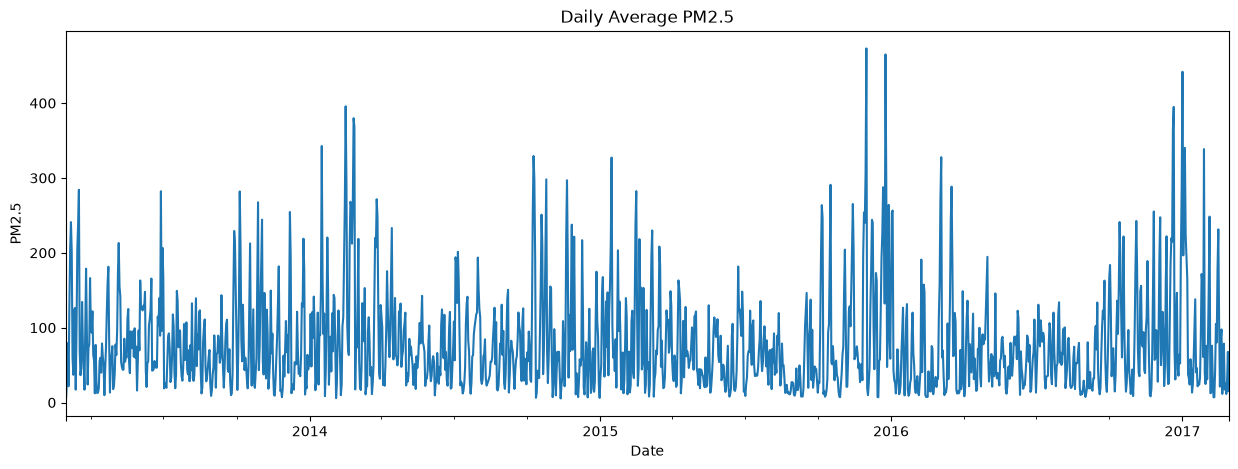

In [40]:
daily_pm25 = (
    df.set_index('datetime')['PM2.5']
      .resample('D')
      .mean()
)

daily_pm25.plot(figsize=(15, 5), title='Daily Average PM2.5')

import matplotlib.pyplot as plt

plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.show()

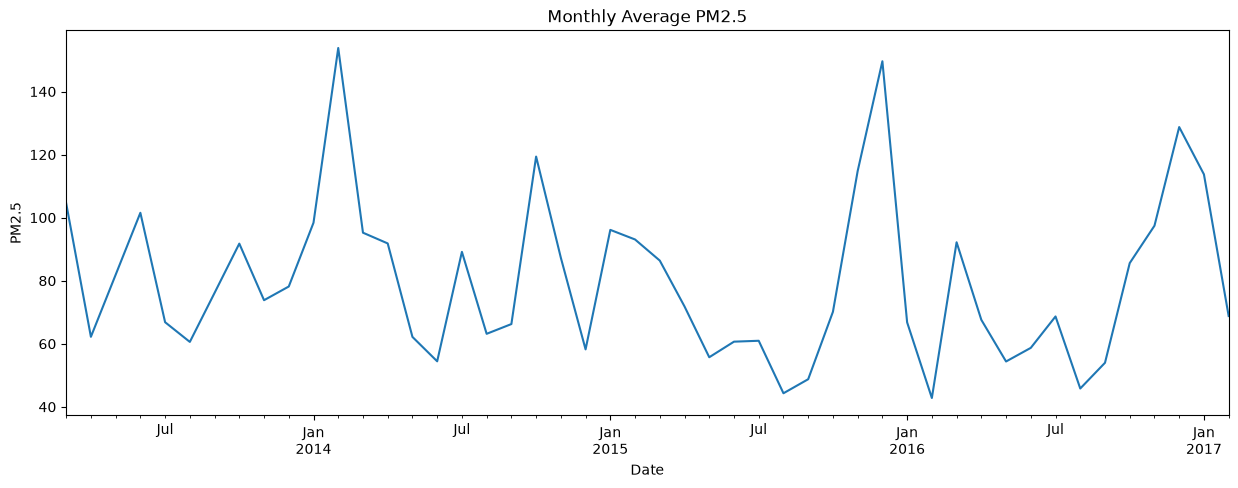

In [41]:
monthly_pm25 = (
    df.set_index('datetime')['PM2.5']
      .resample('ME')
      .mean()
)

monthly_pm25.plot(figsize=(15, 5), title='Monthly Average PM2.5')

plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.show()

The graph repeatedly rises and falls.

The peaks have different magnitudes, so the pattern isn't perfectly regular.

I noticed particularly pronounced periods around 2014 and 2016.

This means a simple linear trend probably won't capture the behavior very well.


## Check seasonality

Average PM2.5 by hour

In [42]:
hourly_pattern = df.groupby('hour')['PM2.5'].mean()

print(hourly_pattern)

hour
0     87.696481
1     86.848406
2     84.794860
3     82.212727
4     79.465989
5     76.538028
6     74.289174
7     73.424078
8     74.403840
9     76.061597
10    77.126229
11    77.142663
12    76.548181
13    76.048575
14    75.462557
15    74.560780
16    74.399300
17    75.524938
18    78.014513
19    82.503641
20    86.636117
21    88.813470
22    89.032249
23    88.595867
Name: PM2.5, dtype: float64


The PM2.5 averages show a clear daily pattern:

- Around 03:00–07:00, PM2.5 falls to its lowest levels.

- It begins increasing again later in the day.

- The highest averages occur around 21:00–23:00, reaching about 89.

- Around midnight, it remains high before declining again.

So hour of day is definitely a useful forecasting feature.

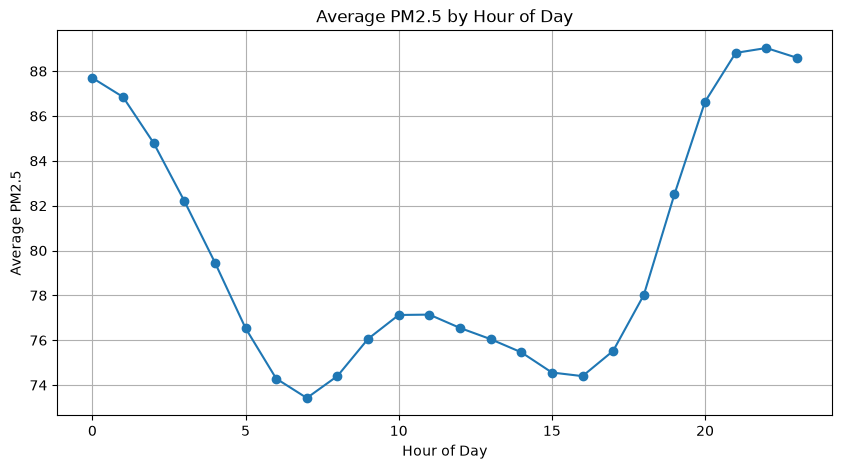

In [43]:
hourly_pattern.plot(
    figsize=(10, 5),
    marker='o',
    title='Average PM2.5 by Hour of Day'
)

plt.xlabel('Hour of Day')
plt.ylabel('Average PM2.5')
plt.grid()
plt.show()

Average PM2.5 by month

In [44]:
monthly_pattern = df.groupby('month')['PM2.5'].mean()

print(monthly_pattern)

month
1      93.760559
2      89.208551
3      94.594295
4      73.367153
5      63.541148
6      68.837547
7      71.401115
8      53.465479
9      61.281071
10     91.715859
11     93.323963
12    103.679184
Name: PM2.5, dtype: float64


**There are substantial differences as December's average is almost twice August's.**

**So month should also be included as a forecasting feature.**

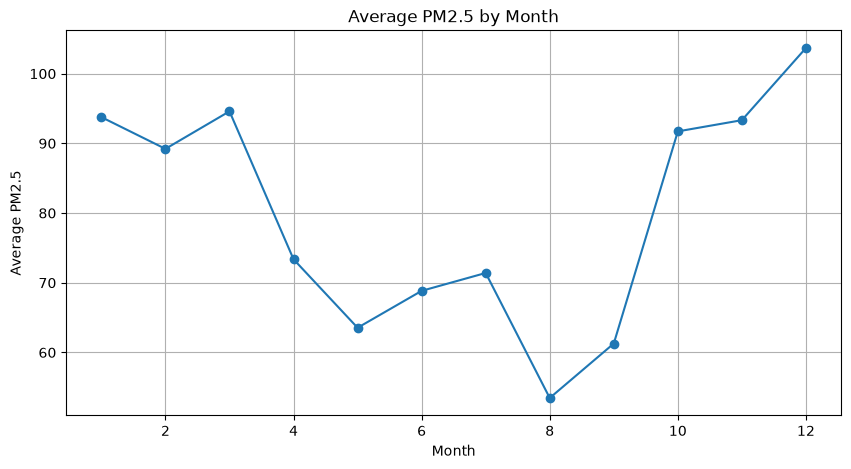

In [45]:
monthly_pattern.plot(
    figsize=(10, 5),
    marker='o',
    title='Average PM2.5 by Month'
)

plt.xlabel('Month')
plt.ylabel('Average PM2.5')
plt.grid()
plt.show()

Average PM2.5 by station

In [46]:
station_pattern = (
    df.groupby('station')['PM2.5']
      .mean()
      .sort_values(ascending=False)
)

print(station_pattern)

station
Dongsi           86.144243
Nongzhanguan     85.079472
Wanshouxigong    85.063056
Gucheng          84.074802
Wanliu           83.467612
Guanyuan         82.897522
Aotizhongxin     82.540623
Tiantan          82.033097
Shunyi           79.437962
Changping        70.986438
Huairou          69.501747
Dingling         66.845557
Name: PM2.5, dtype: float64


**The stations also have noticeably different average PM2.5 levels.**

**This tells us that station/location matters.**

### Create forecasting features

In [47]:
df = df.sort_values(['station', 'datetime'])

df['PM2.5_lag_1'] = df.groupby('station')['PM2.5'].shift(1)
df['PM2.5_lag_3'] = df.groupby('station')['PM2.5'].shift(3)
df['PM2.5_lag_6'] = df.groupby('station')['PM2.5'].shift(6)
df['PM2.5_lag_24'] = df.groupby('station')['PM2.5'].shift(24)

In [48]:
print(df[['datetime', 'station', 'PM2.5',
           'PM2.5_lag_1', 'PM2.5_lag_3',
           'PM2.5_lag_6', 'PM2.5_lag_24']].head(30))

              datetime       station  PM2.5  PM2.5_lag_1  PM2.5_lag_3  \
0  2013-03-01 00:00:00  Aotizhongxin    4.0          NaN          NaN   
1  2013-03-01 01:00:00  Aotizhongxin    8.0          4.0          NaN   
2  2013-03-01 02:00:00  Aotizhongxin    7.0          8.0          NaN   
3  2013-03-01 03:00:00  Aotizhongxin    6.0          7.0          4.0   
4  2013-03-01 04:00:00  Aotizhongxin    3.0          6.0          8.0   
5  2013-03-01 05:00:00  Aotizhongxin    5.0          3.0          7.0   
6  2013-03-01 06:00:00  Aotizhongxin    3.0          5.0          6.0   
7  2013-03-01 07:00:00  Aotizhongxin    3.0          3.0          3.0   
8  2013-03-01 08:00:00  Aotizhongxin    3.0          3.0          5.0   
9  2013-03-01 09:00:00  Aotizhongxin    3.0          3.0          3.0   
10 2013-03-01 10:00:00  Aotizhongxin    3.0          3.0          3.0   
11 2013-03-01 11:00:00  Aotizhongxin    3.0          3.0          3.0   
12 2013-03-01 12:00:00  Aotizhongxin    3.0        

Lag features are working correctly.

### Prepare the modelling set

In [49]:
lag_cols = [
    'PM2.5_lag_1',
    'PM2.5_lag_3',
    'PM2.5_lag_6',
    'PM2.5_lag_24'
]

df_model = df.dropna(subset=lag_cols).copy()

print("Original rows:", len(df))
print("Rows after lag creation:", len(df_model))
print("Missing values:")
print(df_model[lag_cols].isna().sum())

Original rows: 420768
Rows after lag creation: 420480
Missing values:
PM2.5_lag_1     0
PM2.5_lag_3     0
PM2.5_lag_6     0
PM2.5_lag_24    0
dtype: int64


In [50]:
print(df_model.columns.tolist())

['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station', 'datetime', 'PM2.5_lag_1', 'PM2.5_lag_3', 'PM2.5_lag_6', 'PM2.5_lag_24']


## Prepare the forecasting target

Create the future target

In [51]:

# Sort observations chronologically within each station
df = df.sort_values(['station', 'datetime']).copy()

# Create a target representing PM2.5 one hour into the future
df['PM2.5_target'] = (
    df.groupby('station')['PM2.5'].shift(-1)
)

# View the current PM2.5 and future target
df[['station', 'datetime', 'PM2.5', 'PM2.5_target']].head(10)

,station,datetime,PM2.5,PM2.5_target
0,Aotizhongxin,2013-03-01 00:00:00,4.0,8.0
1,Aotizhongxin,2013-03-01 01:00:00,8.0,7.0
2,Aotizhongxin,2013-03-01 02:00:00,7.0,6.0
3,Aotizhongxin,2013-03-01 03:00:00,6.0,3.0
4,Aotizhongxin,2013-03-01 04:00:00,3.0,5.0
5,Aotizhongxin,2013-03-01 05:00:00,5.0,3.0
6,Aotizhongxin,2013-03-01 06:00:00,3.0,3.0
7,Aotizhongxin,2013-03-01 07:00:00,3.0,3.0
8,Aotizhongxin,2013-03-01 08:00:00,3.0,3.0
9,Aotizhongxin,2013-03-01 09:00:00,3.0,3.0


Remove rows without a future target

In [52]:

df_model = df.dropna(subset=['PM2.5_target']).copy()

print("Original dataset shape:", df.shape)
print("Forecasting dataset shape:", df_model.shape)
print("Missing future targets:", df_model['PM2.5_target'].isna().sum())

Original dataset shape: (420768, 24)
Forecasting dataset shape: (420756, 24)
Missing future targets: 0


Check your feature columns

In [53]:

print(df_model.columns.tolist())

['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station', 'datetime', 'PM2.5_lag_1', 'PM2.5_lag_3', 'PM2.5_lag_6', 'PM2.5_lag_24', 'PM2.5_target']


Select the features and target

In [54]:

# Define the predictor columns
features = [
    'PM2.5_lag_1',
    'PM2.5_lag_3',
    'PM2.5_lag_6',
    'PM2.5_lag_24',
    'PM10',
    'SO2',
    'NO2',
    'CO',
    'O3',
    'TEMP',
    'PRES',
    'DEWP',
    'RAIN',
    'WSPM',
    'hour',
    'month',
    'station'
]

# Create X (predictor variables) and y (target variable)
X = df_model[features].copy()
y = df_model['PM2.5_target'].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nMissing values in features:")
print(X.isna().sum().sum())

print("\nMissing values in target:")
print(y.isna().sum())

Features shape: (420756, 17)
Target shape: (420756,)

Missing values in features:
408

Missing values in target:
0


**Even though the original dataset was cleaned earlier, missing values can still appear in the lag features because the first observations at each station don't have enough historical data.**

Identify where the missing values are

In [55]:

missing_counts = X.isna().sum()

print(missing_counts[missing_counts > 0])

PM2.5_lag_1      12
PM2.5_lag_3      36
PM2.5_lag_6      72
PM2.5_lag_24    288
dtype: int64


Handle missing values

In [56]:

# Keep rows where all predictors are available
valid_rows = X.notna().all(axis=1)

X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].copy()

# Keep df_model aligned with X and y
df_model = df_model.loc[valid_rows].copy()

print("Features shape after cleaning:", X.shape)
print("Target shape after cleaning:", y.shape)
print("Remaining missing values:", X.isna().sum().sum())

Features shape after cleaning: (420468, 17)
Target shape after cleaning: (420468,)
Remaining missing values: 0


### Encoding

In [59]:

# Convert station names into numerical indicator columns
X = pd.get_dummies(
    X,
    columns=['station'],
    drop_first=True,
    dtype=int
)

print("Encoded features shape:", X.shape)
print(X.head())

Encoded features shape: (420468, 27)
    PM2.5_lag_1  PM2.5_lag_3  PM2.5_lag_6  PM2.5_lag_24  PM10   SO2   NO2  \
24         24.0         12.0         11.0           4.0  24.0  24.0  44.0   
25         22.0         15.0          8.0           8.0  17.0  21.0  36.0   
26         14.0         24.0         11.0           7.0  13.0  20.0  37.0   
27         13.0         22.0         12.0           6.0   9.0  13.0  34.0   
28          3.0         14.0         15.0           3.0   7.0  18.0  43.0   

       CO    O3  TEMP  ...  station_Dingling  station_Dongsi  \
24  500.0  44.0  -0.4  ...                 0               0   
25  400.0  50.0  -1.0  ...                 0               0   
26  400.0  47.0  -1.5  ...                 0               0   
27  400.0  52.0  -1.4  ...                 0               0   
28  400.0  43.0  -1.5  ...                 0               0   

    station_Guanyuan  station_Gucheng  station_Huairou  station_Nongzhanguan  \
24                 0               

Split the data chronologically

In [60]:

# Sort the data by datetime
df_model = df_model.sort_values('datetime').copy()

# Select the cutoff date at 80% of the timeline
split_date = df_model['datetime'].quantile(0.8)

# Split chronologically
train_mask = df_model['datetime'] < split_date
test_mask = df_model['datetime'] >= split_date

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Split date:", split_date)
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Split date: 2016-05-12 23:00:00
Training observations: 336372
Testing observations: 84096


**Training data: the model learns relationships between historical conditions and future PM2.5.**

**Testing data: to assess how well it predicts a later period it hasn't trained on.**

Train the Random Forest model

In [61]:

from sklearn.ensemble import RandomForestRegressor

# Initialize the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [62]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values in X:")
print(X.isna().sum().sum())

print("\nMissing values in y:")
print(y.isna().sum())

print("\nData types:")
print(X.dtypes)

X shape: (420468, 27)
y shape: (420468,)

Missing values in X:
0

Missing values in y:
0

Data types:
PM2.5_lag_1              float64
PM2.5_lag_3              float64
PM2.5_lag_6              float64
PM2.5_lag_24             float64
PM10                     float64
SO2                      float64
NO2                      float64
CO                       float64
O3                       float64
TEMP                     float64
PRES                     float64
DEWP                     float64
RAIN                     float64
WSPM                     float64
hour                       int64
month                      int64
station_Changping          int64
station_Dingling           int64
station_Dongsi             int64
station_Guanyuan           int64
station_Gucheng            int64
station_Huairou            int64
station_Nongzhanguan       int64
station_Shunyi             int64
station_Tiantan            int64
station_Wanliu             int64
station_Wanshouxigong      int64
dtype: 

Make the forecasts

In [64]:
y_pred = rf_model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[42.68837662 33.98666667 44.49857143 35.49083333 22.46833333 26.
 16.16       32.74       18.81       26.40625   ]


In [65]:
results = pd.DataFrame({
    'Actual_PM2.5': y_test.values,
    'Predicted_PM2.5': y_pred
})

print(results.head(10))

   Actual_PM2.5  Predicted_PM2.5
0          40.0        42.688377
1          49.0        33.986667
2          39.0        44.498571
3          27.0        35.490833
4           7.0        22.468333
5          34.0        26.000000
6          17.0        16.160000
7          23.0        32.740000
8          26.0        18.810000
9          28.0        26.406250


Calculate MAE and RMSE

In [66]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 11.846882614157526
RMSE: 21.81115050271918


**On average, the predicted PM2.5 concentration is about 11.85 units away from the actual value.**

**So if the actual PM2.5 is 80, the model's prediction might typically be around 68–92, although individual errors vary.**

**RMSE = 21.81**

**The RMSE is considerably higher than the MAE. This indicates that while many predictions are relatively close, there are some larger prediction errors, particularly around sudden PM2.5 spikes.**
**That's actually quite plausible for air-quality forecasting because pollution can change sharply due to weather conditions or other factors.**

Plot actual vs predicted

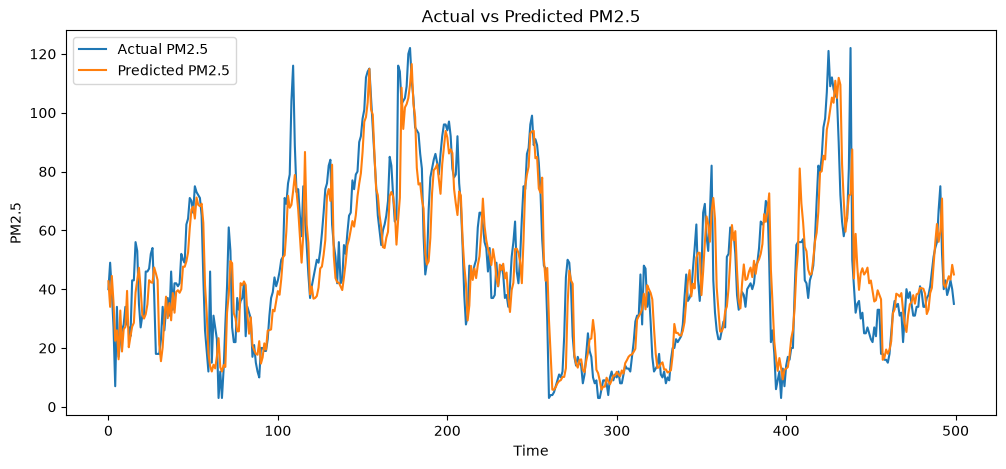

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(y_test.values[:500], label='Actual PM2.5')
plt.plot(y_pred[:500], label='Predicted PM2.5')

plt.title('Actual vs Predicted PM2.5')
plt.xlabel('Time')
plt.ylabel('PM2.5')
plt.legend()
plt.show()

I can't conclude that the model is "good" or "bad" from these two numbers alone. A baseline comparison is required.

A very useful baseline for forecasting is:

- Predict the next hour's PM2.5 as equal to the current hour's PM2.5.

Create the baseline

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Naive forecast: next hour = current hour
baseline_pred = df_model.loc[test_mask, 'PM2.5'].values

# Calculate baseline errors
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 79.8196799576935
Baseline RMSE: 116.63369533740737


**The Random Forest errors are much lower than the naive baseline.**

**MAE decreased from 79.82 → 11.85**

**RMSE decreased from 116.63 → 21.81**

In [69]:
mae_improvement = (baseline_mae - mae) / baseline_mae * 100
rmse_improvement = (baseline_rmse - rmse) / baseline_rmse * 100

print("MAE improvement:", mae_improvement, "%")
print("RMSE improvement:", rmse_improvement, "%")

MAE improvement: 85.15794272736163 %
RMSE improvement: 81.29944315009301 %


**The Random Forest model substantially improved upon the naive forecasting baseline. The model achieved an MAE of 11.85 and an RMSE of 21.81, compared with 79.82 and 116.63 respectively for the baseline model. This indicates that incorporating historical PM2.5 levels, environmental variables, temporal information, and monitoring-station characteristics provides substantially more accurate one-hour-ahead PM2.5 forecasts than simply using the current PM2.5 level as the next-hour prediction.**

## Why the model is performing this way

This tells us which variables the Random Forest relied on most when making its forecasts.

In [70]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

print(feature_importance)

                  Feature  Importance
0             PM2.5_lag_1    0.815064
4                    PM10    0.095846
11                   DEWP    0.009402
13                   WSPM    0.008837
7                      CO    0.008537
6                     NO2    0.006821
3            PM2.5_lag_24    0.006688
2             PM2.5_lag_6    0.006516
1             PM2.5_lag_3    0.006393
5                     SO2    0.006117
9                    TEMP    0.006069
10                   PRES    0.005615
14                   hour    0.005327
8                      O3    0.004605
15                  month    0.002725
12                   RAIN    0.001213
16      station_Changping    0.000521
20        station_Gucheng    0.000480
17       station_Dingling    0.000452
23         station_Shunyi    0.000435
18         station_Dongsi    0.000387
26  station_Wanshouxigong    0.000375
22   station_Nongzhanguan    0.000367
25         station_Wanliu    0.000328
21        station_Huairou    0.000297
24        st

Visualize top 15

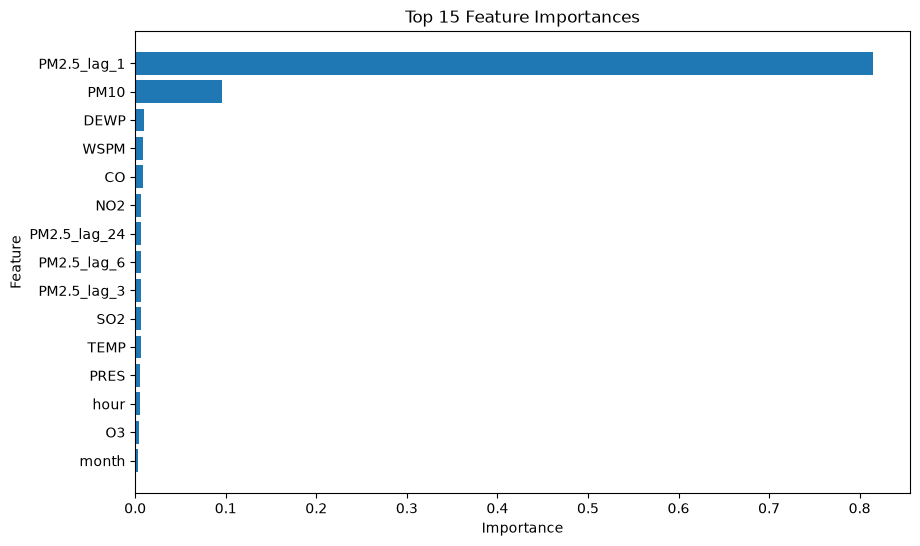

In [71]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(15)

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

- The most important feature by far is PM2.5_lag_1, with an importance of 81.5%.

That makes sense for a one-hour-ahead forecasting problem: the PM2.5 concentration one hour earlier is highly informative about the concentration in the next hour.

- PM10 is the second most important

PM10 has an importance of about 9.6%.

This suggests that the model is also using the current particulate-matter concentration to help forecast future PM2.5.

The rest have a much smaller importance

# Conclusion

**The Random Forest model achieved an MAE of 11.85 and an RMSE of 21.81, substantially outperforming the naive baseline (MAE = 79.82; RMSE = 116.63).** 

**Feature-importance analysis showed that PM2.5 from the previous hour was the dominant predictor (importance = 0.815), followed by PM10 (0.096). Weather and other pollutant variables contributed smaller individual amounts.**

**These results indicate that recent particulate-matter conditions provide the strongest predictive information for one-hour-ahead PM2.5 forecasting in this dataset.**

### Actual vs Predicted plot

Visually see where the model performs well and where it struggles, especially during pollution spikes.

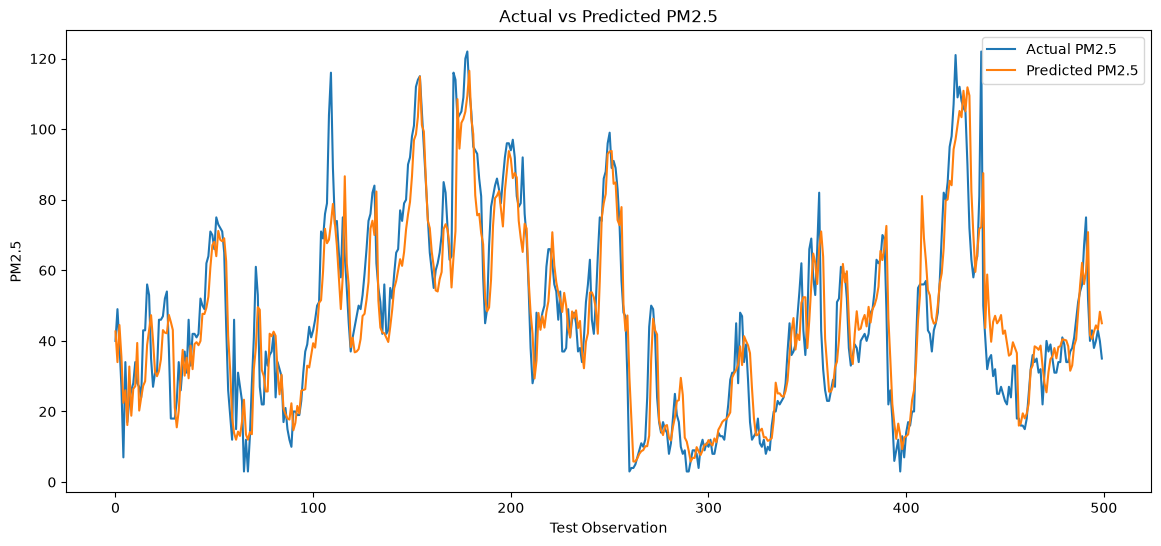

In [72]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_test.values[:500],
    label='Actual PM2.5'
)

plt.plot(
    y_pred[:500],
    label='Predicted PM2.5'
)

plt.title('Actual vs Predicted PM2.5')
plt.xlabel('Test Observation')
plt.ylabel('PM2.5')
plt.legend()

plt.show()

## Check where model makes its biggest errors

In [73]:
results['Error'] = results['Actual_PM2.5'] - results['Predicted_PM2.5']
results['Absolute_Error'] = abs(results['Error'])

print(results['Absolute_Error'].describe())

count    84096.000000
mean        11.846883
std         18.313428
min          0.000000
25%          2.736693
50%          6.430714
75%         13.980000
max        545.445000
Name: Absolute_Error, dtype: float64


That maximum error of 545.45 is unusually large. 

Next is to find out which observation caused it rather than simply ignoring it.

In [74]:
# Find the 10 largest prediction errors
largest_errors = results.sort_values(
    'Absolute_Error',
    ascending=False
).head(10)

print(largest_errors)

       Actual_PM2.5  Predicted_PM2.5       Error  Absolute_Error
82765      3.000000       548.445000 -545.445000      545.445000
82407      3.000000       427.274722 -424.274722      424.274722
48289    556.000000       145.159130  410.840870      410.840870
55654    529.000000       152.080000  376.920000      376.920000
82767    403.000000        42.145000  360.855000      360.855000
40348    558.000000       201.352222  356.647778      356.647778
26703      3.000000       341.186167 -338.186167      338.186167
17646    363.958904        29.730000  334.228904      334.228904
17645    367.808219        34.550000  333.258219      333.258219
40393     25.000000       357.907143 -332.907143      332.907143


In [75]:
# Check the highest PM2.5 values in the original cleaned dataset
print(
    df[['station', 'datetime', 'PM2.5']]
    .sort_values('PM2.5', ascending=False)
    .head(20)
)

              station            datetime  PM2.5
376418         Wanliu 2016-02-08 02:00:00  957.0
306290         Shunyi 2016-02-08 02:00:00  941.0
25778    Aotizhongxin 2016-02-08 02:00:00  898.0
60842       Changping 2016-02-08 02:00:00  882.0
95905        Dingling 2016-02-08 01:00:00  881.0
411483  Wanshouxigong 2016-02-08 03:00:00  857.0
247020   Nongzhanguan 2013-05-05 12:00:00  844.0
411482  Wanshouxigong 2016-02-08 02:00:00  841.5
279746   Nongzhanguan 2017-01-28 02:00:00  835.0
411481  Wanshouxigong 2016-02-08 01:00:00  826.0
420003  Wanshouxigong 2017-01-28 03:00:00  823.0
341355        Tiantan 2016-02-08 03:00:00  821.0
306289         Shunyi 2016-02-08 01:00:00  816.0
253872   Nongzhanguan 2014-02-15 00:00:00  809.0
349875        Tiantan 2017-01-28 03:00:00  808.0
420001  Wanshouxigong 2017-01-28 01:00:00  804.0
341356        Tiantan 2016-02-08 04:00:00  801.0
376420         Wanliu 2016-02-08 04:00:00  791.0
253873   Nongzhanguan 2014-02-15 01:00:00  781.0
183742        Guchen

## Create an improved version

With additional time-series features and see whether the MAE/RMSE improves.

In [76]:
# Sort by station and time
df = df.sort_values(['station', 'datetime']).copy()

# Previous-hour PM2.5 change
df['PM2.5_change_1h'] = (
    df.groupby('station')['PM2.5'].diff(1)
)

# Three-hour PM2.5 change
df['PM2.5_change_3h'] = (
    df.groupby('station')['PM2.5'].diff(3)
)

print(
    df[['station', 'datetime', 'PM2.5',
        'PM2.5_change_1h', 'PM2.5_change_3h']].head(10)
)

        station            datetime  PM2.5  PM2.5_change_1h  PM2.5_change_3h
0  Aotizhongxin 2013-03-01 00:00:00    4.0              NaN              NaN
1  Aotizhongxin 2013-03-01 01:00:00    8.0              4.0              NaN
2  Aotizhongxin 2013-03-01 02:00:00    7.0             -1.0              NaN
3  Aotizhongxin 2013-03-01 03:00:00    6.0             -1.0              2.0
4  Aotizhongxin 2013-03-01 04:00:00    3.0             -3.0             -5.0
5  Aotizhongxin 2013-03-01 05:00:00    5.0              2.0             -2.0
6  Aotizhongxin 2013-03-01 06:00:00    3.0             -2.0             -3.0
7  Aotizhongxin 2013-03-01 07:00:00    3.0              0.0              0.0
8  Aotizhongxin 2013-03-01 08:00:00    3.0              0.0             -2.0
9  Aotizhongxin 2013-03-01 09:00:00    3.0              0.0              0.0


Check the change features

In [77]:
print(df[['PM2.5_change_1h', 'PM2.5_change_3h']].describe())

       PM2.5_change_1h  PM2.5_change_3h
count    420756.000000    420732.000000
mean          0.000266         0.000746
std          20.040245        38.849970
min        -628.000000      -784.000000
25%          -5.000000        -9.000000
50%           0.000000         1.000000
75%           6.000000        13.000000
max         853.000000       863.000000


In [78]:
print(df[['PM2.5_change_1h', 'PM2.5_change_3h']].isna().sum())

PM2.5_change_1h    12
PM2.5_change_3h    36
dtype: int64


In [79]:
print(df[['station', 'datetime', 'PM2.5', 
          'PM2.5_lag_1', 'PM2.5_lag_3', 'PM2.5_lag_6', 'PM2.5_lag_24',
          'PM2.5_change_1h', 'PM2.5_change_3h',
          'PM2.5_target']].head(10))

        station            datetime  PM2.5  PM2.5_lag_1  PM2.5_lag_3  \
0  Aotizhongxin 2013-03-01 00:00:00    4.0          NaN          NaN   
1  Aotizhongxin 2013-03-01 01:00:00    8.0          4.0          NaN   
2  Aotizhongxin 2013-03-01 02:00:00    7.0          8.0          NaN   
3  Aotizhongxin 2013-03-01 03:00:00    6.0          7.0          4.0   
4  Aotizhongxin 2013-03-01 04:00:00    3.0          6.0          8.0   
5  Aotizhongxin 2013-03-01 05:00:00    5.0          3.0          7.0   
6  Aotizhongxin 2013-03-01 06:00:00    3.0          5.0          6.0   
7  Aotizhongxin 2013-03-01 07:00:00    3.0          3.0          3.0   
8  Aotizhongxin 2013-03-01 08:00:00    3.0          3.0          5.0   
9  Aotizhongxin 2013-03-01 09:00:00    3.0          3.0          3.0   

   PM2.5_lag_6  PM2.5_lag_24  PM2.5_change_1h  PM2.5_change_3h  PM2.5_target  
0          NaN           NaN              NaN              NaN           8.0  
1          NaN           NaN              4.0    

### Rebuild the modeling dataset

Create the modeling dataframe

In [80]:
df_model = df.copy()

df_model = df_model.dropna(subset=[
    'PM2.5_lag_1',
    'PM2.5_lag_3',
    'PM2.5_lag_6',
    'PM2.5_lag_24',
    'PM2.5_change_1h',
    'PM2.5_change_3h',
    'PM2.5_target'
])

print(df_model.shape)

(420468, 26)


Define the features

In [81]:
features = [
    'PM2.5_lag_1',
    'PM2.5_lag_3',
    'PM2.5_lag_6',
    'PM2.5_lag_24',
    'PM2.5_change_1h',
    'PM2.5_change_3h',
    'PM10',
    'SO2',
    'NO2',
    'CO',
    'O3',
    'TEMP',
    'PRES',
    'DEWP',
    'RAIN',
    'WSPM',
    'hour',
    'month',
    'station'
]

X = df_model[features].copy()
y = df_model['PM2.5_target'].copy()

Encoding

In [82]:
X = pd.get_dummies(
    X,
    columns=['station'],
    drop_first=True,
    dtype=int
)

Check X and y

In [83]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Missing values in X:", X.isna().sum().sum())
print("Missing values in y:", y.isna().sum())

X shape: (420468, 29)
y shape: (420468,)
Missing values in X: 0
Missing values in y: 0


Sort by time

In [84]:
df_model = df_model.sort_values('datetime').copy()

Create the 80/20 chronological split

In [85]:
split_date = df_model['datetime'].quantile(0.8)

train_mask = df_model['datetime'] < split_date
test_mask = df_model['datetime'] >= split_date

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Split date:", split_date)

Training data: (336372, 29)
Testing data: (84096, 29)
Split date: 2016-05-12 23:00:00


Check the dates

In [86]:
print("Training period:")
print(df_model.loc[train_mask, 'datetime'].min())
print(df_model.loc[train_mask, 'datetime'].max())

print("\nTesting period:")
print(df_model.loc[test_mask, 'datetime'].min())
print(df_model.loc[test_mask, 'datetime'].max())

Training period:
2013-03-02 00:00:00
2016-05-12 22:00:00

Testing period:
2016-05-12 23:00:00
2017-02-28 22:00:00


Train the improved model

In [87]:
from sklearn.ensemble import RandomForestRegressor

rf_improved = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_improved.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [88]:
y_pred_improved = rf_improved.predict(X_test)

In [89]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_improved = mean_absolute_error(y_test, y_pred_improved)
rmse_improved = np.sqrt(mean_squared_error(y_test, y_pred_improved))

print("Improved Random Forest MAE:", mae_improved)
print("Improved Random Forest RMSE:", rmse_improved)

Improved Random Forest MAE: 9.512947784811365
Improved Random Forest RMSE: 17.946923362403457


In [90]:
mae_improvement = (11.846882614157526 - mae_improved) / 11.846882614157526 * 100
rmse_improvement = (21.81115050271918 - rmse_improved) / 21.81115050271918 * 100

print("MAE improvement:", mae_improvement, "%")
print("RMSE improvement:", rmse_improvement, "%")

MAE improvement: 19.700835277602987 %
RMSE improvement: 17.716750612646376 %


So adding the 1-hour and 3-hour PM2.5 change features reduced the average absolute error by about one-fifth.

### Actual vs Predicted plot

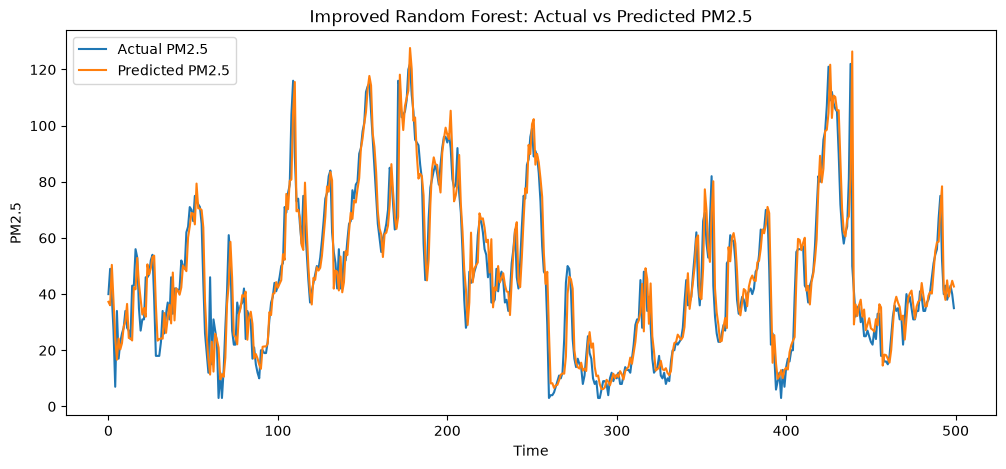

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values[:500],
    label='Actual PM2.5'
)

plt.plot(
    y_pred_improved[:500],
    label='Predicted PM2.5'
)

plt.title('Improved Random Forest: Actual vs Predicted PM2.5')
plt.xlabel('Time')
plt.ylabel('PM2.5')
plt.legend()

plt.show()

### Model Conclusion

The Random Forest model successfully predicted one-hour-ahead PM2.5 concentrations using historical air-quality, weather, time, station, and temporal change features. The original Random Forest achieved an MAE of **11.85** and an RMSE of **21.81**, while the improved model, which incorporated 1-hour and 3-hour PM2.5 change features, reduced these errors to an MAE of **9.51** and an RMSE of **17.95**.

This represents an improvement of approximately **19.7% in MAE** and **17.7% in RMSE** compared with the original Random Forest. The results indicate that information about the recent direction and magnitude of PM2.5 changes provides additional predictive value beyond using lagged pollution levels alone.

The improved model also substantially outperformed the naive persistence baseline, which had an MAE of **79.82** and an RMSE of **116.63**. 

Overall, the results demonstrate that recent historical pollution patterns, combined with environmental and temporal variables, can be used effectively for short-term air-quality forecasting. 

However, the remaining difference between MAE and RMSE indicates that the model can still experience larger errors during sudden or extreme changes in pollution levels.
